<a href="https://colab.research.google.com/github/konstantinamalt/konstantinamalt.github.io/blob/main/MASTERCLASS_DH26_copernicus_api_requests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Libraries we want to initialize for our code to work

each of them serves a different purpose

In [12]:
import pandas as pd
import requests
import time
import numpy as np
from tqdm import tqdm
import json

pandas → tables & spreadsheets

requests → talk to the internet

time → delays & timing

numpy → fast math & arrays (list of numbers that Python can process all at once instead of one by one)

tqdm → progress bars

json → read/write web data

We will focus on flood data from **Copernicus Emergency Mapping Service**.

### Where do we get the flood data?

https://mapping.emergency.copernicus.eu/activations/

The link lists **all natural disasters captured by Copernicus EMS service**.

**Note on activations data**: National authorities ask the satellite service to monitor the national disasters. It works globally but it does not contain ALL floods EVER. The monitoring with data on flooded hectares and type of land affected we want starts in 2023.

### How do we get the floods for EU or for our country?

Write in the search bar "**flood**" or the country we want, like "Greece" (if you write just the country of interest all natural disasters observed for that country will appear not only floods).

**Note**: The search bar is simple text based search, if you write "floods" instead of "flood" you're only going to get exact matches, so less data.

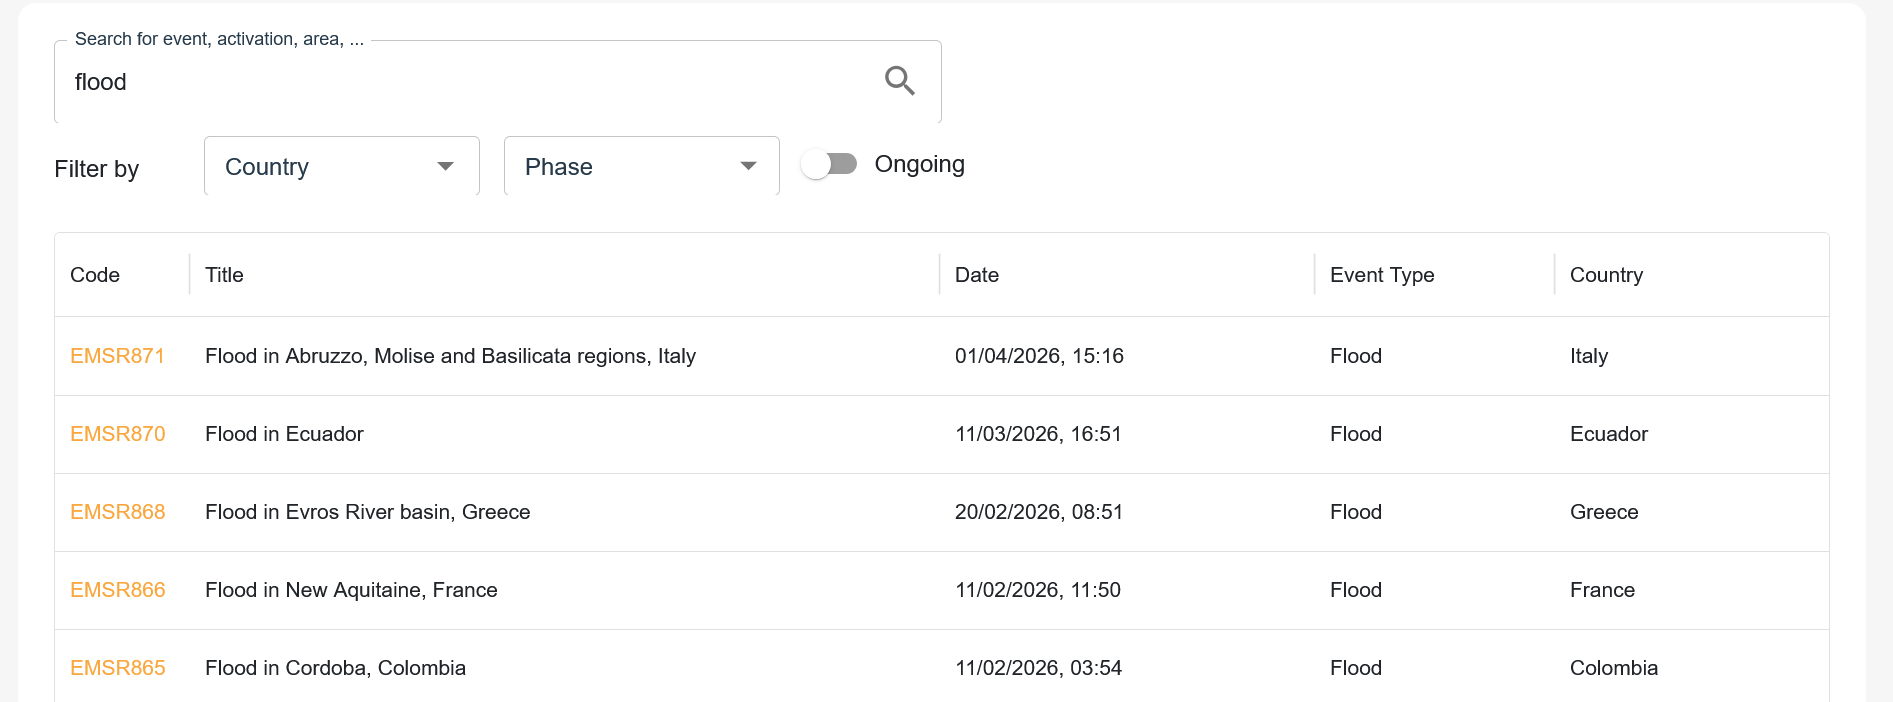

Or floods for the country you want by filtering the "**Country**" section:

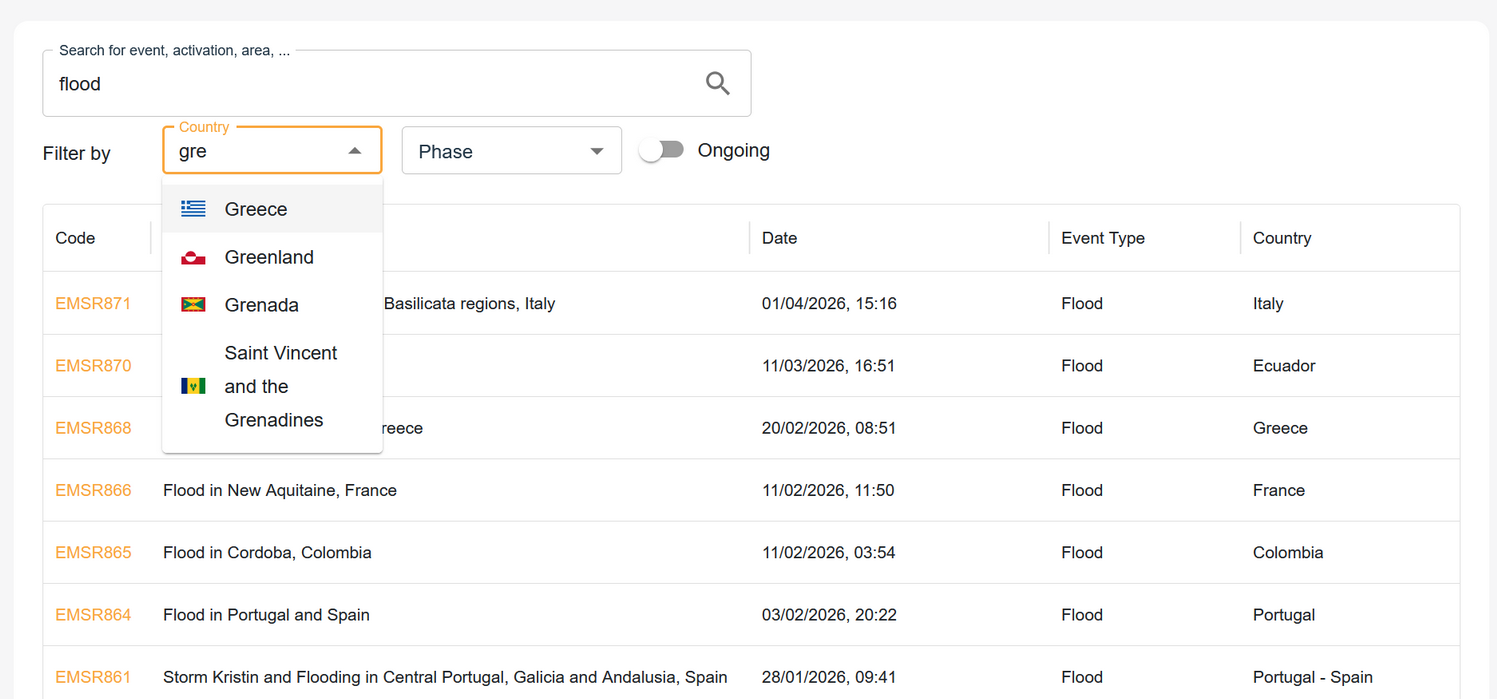

The column "**Code**" on the left is a **unique id** given to each event observed by Copernicus EMS. Each of the events has its own website (you can click on it!).

Why do we need to know what it is? It's the code we're goind to use to scrape Coprnicus API and get the data for each flood!

Before we do that, we need to collect all unique ids of the floods in our country. After we have filtered with the keyword "flood" (and NOT floodS) and chosen the name of the country of interest in the appropriate section, we click on the "**EXPORT EXCEL**" option at the bottom right of the page. (you can export as csv but then you would have to deal with separators in google collab..)

fix if you doenload csv= df = pd.read_csv('activations.csv', sep=';')

**IF THERE ARE MORE THAN 20 (YOU'LL SEE ROWS HIGHLIGHTED) YOU HAVE TO CLOCK ON THE ARROW AND GET THE NEXT 20 AND THE NEXT 20 etc**. They don't let you download them all at once...

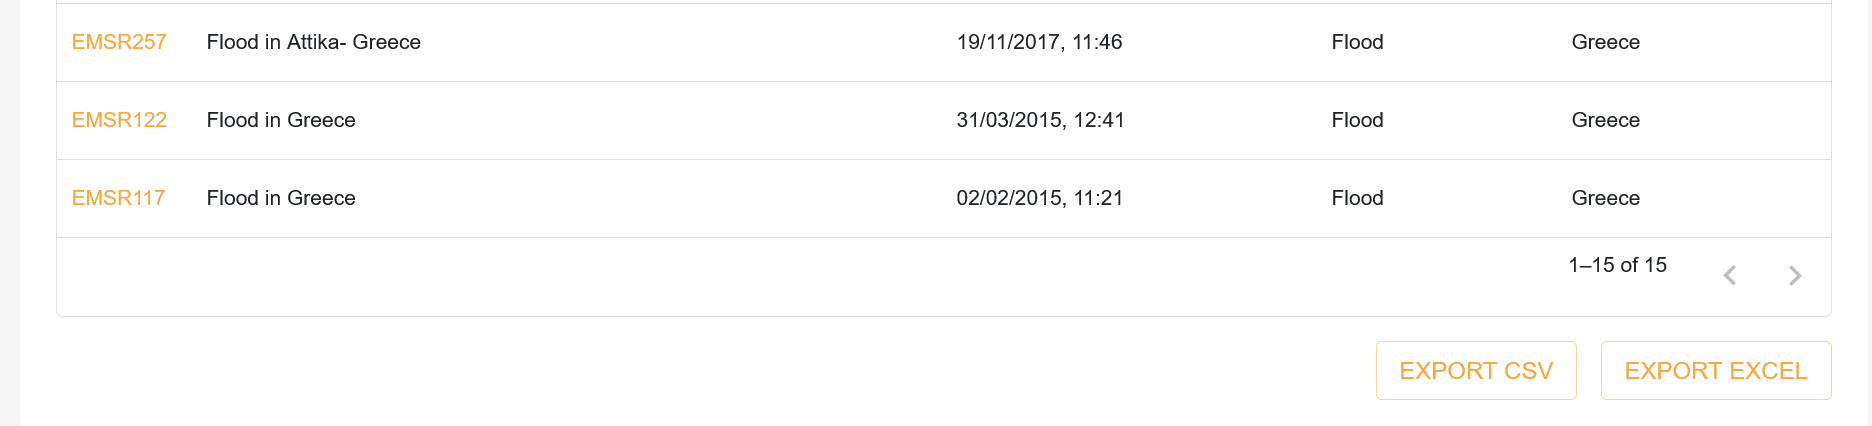

Import your data with the unique flood ids in this google collab notebook and then read it!

In [11]:
from google.colab import files
uploaded = files.upload()

Saving activations.xlsx to activations (1).xlsx


In [13]:
df = pd.read_excel('activations.xlsx')
df.head()

,Code,Title,Date,Event Type,Country
0,EMSR868,"Flood in Evros River basin, Greece","20/02/2026, 08:51",Flood,Greece
1,EMSN184,"Flood in Thessaly Region, Greece","23/11/2023, 00:00",Flood,Greece
2,EMSR697,"Flood in Thessaly and Sterea Ellada regions, G...","26/09/2023, 10:32",Flood,Greece
3,EMSR692,Flood in Greece,"05/09/2023, 12:10",Flood,Greece
4,EMSR480,Flood in Crete Region- Greece,"11/11/2020, 07:57",Flood,Greece


If you have more than one excels you run the following code

Now we will put all the unique ids in a **list**!

In [61]:
from google.colab import files
uploaded = files.upload()

Saving activations_gr.xlsx to activations_gr.xlsx


In [70]:
df = pd.read_excel(list(uploaded.keys())[0]) #collab needs this too get the most updated file..
df

,Code,Title,Date,Event Type,Country
0,EMSR868,"Flood in Evros River basin, Greece","20/02/2026, 08:51",Flood,Greece
1,EMSN184,"Flood in Thessaly Region, Greece","23/11/2023, 00:00",Flood,Greece
2,EMSR697,"Flood in Thessaly and Sterea Ellada regions, G...","26/09/2023, 10:32",Flood,Greece
3,EMSR692,Flood in Greece,"05/09/2023, 12:10",Flood,Greece
4,EMSR480,Flood in Crete Region- Greece,"11/11/2020, 07:57",Flood,Greece
5,EMSR465,Floods in Thessaly Region- Greece,"19/09/2020, 09:46",Flood,Greece
6,EMSR413,Flood in western Attika- Greece,"26/11/2019, 12:34",Flood,Greece
7,EMSR337,Flood in Western Greece,"14/01/2019, 13:14",Flood,Greece
8,EMSR294,Floods west of Athens- Greece,"03/07/2018, 11:33",Flood,Greece
9,EMSR292,Flood in North Eastern Greece,"29/06/2018, 10:26",Flood,Greece


In [71]:
floods = df['Code'].to_list() #if you have only ONE EXCEL if you have multiple please change the name to merged_df
floods

['EMSR868',
 'EMSN184',
 'EMSR697',
 'EMSR692',
 'EMSR480',
 'EMSR465',
 'EMSR413',
 'EMSR337',
 'EMSR294',
 'EMSR292',
 'EMSR277',
 'EMSR271',
 'EMSR257',
 'EMSR122',
 'EMSR117']

In [ ]:
# if you have more than one take out the "#" below, delete the code above, and run the cell

# dfs = []  # list to store each file's dataframe

# for filename in uploaded.keys():
#     df = pd.read_excel(filename)
#     dfs.append(df)

# # merge all into one dataframe
# merged_df = pd.concat(dfs, ignore_index=True)
# merged_df

Now we will use this list to get the data for each one of these floods.

## Collecting the data for each flood

We will scrape Copernicus' API, which is like talking to Copernicus' computer, asking it ("requests") exactly what you want and getting back a clean, structured answer back, without clicking through websites.

Let's check out one flood:
https://rapidmapping.emergency.copernicus.eu/backend/dashboard-api/public-activations/?format=json&code=EMSR692

See "EMSR692" at the end of the api? This is the unique code we talked about.

You can check its website: https://mapping.emergency.copernicus.eu/activations/EMSR692/

Now ee have collected all the floods for our country of interest its in the list called "floods" (you can re-name it whatever you want just remember to re-name it in the scraping code too) we're going to loop through each flood id to get data as when and where the flood occured flood extent (in hectares) type of land affected in (agriculture, natural ecosystems, infrastructure etc) and population.

We will take all days of observation so multiple rows for own flood that correspond to multiple products (days and types of observation) and multiple areas of interest (the area drawn out by Copernicus where the flood occured, it's not connected to administrative boundaries!)

In [89]:
!pip install shapely geopandas

In [91]:
from shapely import wkt #these two libraries are not included by default in google collab
import geopandas as gpd

Now lets get the AOI polygons so we can keep the ones that do not overlap with each other.

In [92]:
products_data = []

for flood in tqdm(floods):
    url = f'https://rapidmapping.emergency.copernicus.eu/backend/dashboard-api/public-activations/?format=json&code={flood}'
    response = requests.get(url)
    time.sleep(10)
    data = response.json()

    # --- SAFETY CHECKS ---
    if not isinstance(data, dict):
        continue
    if "results" not in data or not data["results"]:
        continue
    if "aois" not in data["results"][0]:
        continue

    aois = data["results"][0]["aois"]
    if not aois:
        continue
    # ----------------------

    for aoi in aois:

        # AOI generic info
        aois_data_generic = {
            "name": aoi.get("name", np.nan),
            "number": aoi.get("number", np.nan),
            "activationCode": aoi.get("activationCode", np.nan)
        }

        products = aoi.get('products', [])
        if not products:
            continue

        for product in products:

            # Product-level info
            aois_data_products = {
                "activation_code": product.get("activationCode", np.nan),
                "aoiName": product.get("aoiName", np.nan),
                "aoiNumber": product.get("aoiNumber", np.nan),
                "type": product.get("type", np.nan),
                "monitoring": product.get("monitoringNumber", np.nan),
                "product_polygon": product.get("extent", np.nan)   # NEW COLUMN
            }

            # Version info
            version = product.get('version')
            version_data = {
                "deliveryTime": version.get("deliveryTime", np.nan) if version else np.nan
            }

            # --- JSON EXTRACTION ---
            json_urls = []
            layers = product.get("layers", [])

            for layer in layers:
                json_field = layer.get("json")

                # Case A: list of JSON objects
                if isinstance(json_field, list):
                    for entry in json_field:
                        href = entry.get("href", "")
                        if isinstance(href, str) and href.endswith(".json"):
                            json_urls.append(href)

                # Case B: single JSON string
                elif isinstance(json_field, str) and json_field.endswith(".json"):
                    json_urls.append(json_field)

                # Case C: JSONs inside "files"
                files = layer.get("files", [])
                for f in files:
                    for v in f.values():
                        if isinstance(v, str) and v.endswith(".json"):
                            json_urls.append(v)

            # Prioritize JSONs
            priority_json = np.nan
            if json_urls:
                for key in ["maximumwaterextent", "observedevent", "previous"]:
                    for u in json_urls:
                        if key in u.lower():
                            priority_json = u
                            break
                    if priority_json is not np.nan:
                        break
                if priority_json is np.nan:
                    priority_json = json_urls[0]

            # Stats extraction
            stats = product.get('stats')
            if stats:
                for category, subcategories in stats.items():
                    if isinstance(subcategories, dict):
                        for subcategory, values in subcategories.items():
                            subcategory_unit = f"{category}_{subcategory}_({values.get('unit', np.nan)})"
                            affected = values.get('affected', np.nan)
                            total = values.get('total', np.nan)

                            product_stat_all = {
                                **aois_data_generic,
                                **aois_data_products,
                                "deliveryTime": version_data["deliveryTime"],
                                "subcategory_unit": subcategory_unit,
                                "affected": affected,
                                "total": total,
                                "json_url": priority_json,
                                "all_json_urls": json_urls
                            }
                            products_data.append(product_stat_all)
            else:
                product_stat_all = {
                    **aois_data_generic,
                    **aois_data_products,
                    "deliveryTime": version_data["deliveryTime"],
                    "subcategory_unit": np.nan,
                    "affected": np.nan,
                    "total": np.nan,
                    "json_url": priority_json,
                    "all_json_urls": json_urls
                }
                products_data.append(product_stat_all)

# Convert to DataFrame
aois_df = pd.DataFrame(products_data)
aois_df

100%|██████████| 15/15 [02:38<00:00, 10.55s/it]


,name,number,activationCode,activation_code,aoiName,aoiNumber,type,monitoring,product_polygon,deliveryTime,subcategory_unit,affected,total,json_url,all_json_urls
0,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-21T13:58:57.271048,Built-up_Military_(ha),0.2,629.1,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
1,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-21T13:58:57.271048,Built-up_Residential Buildings_(ha),2.0,1534.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
2,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-21T13:58:57.271048,Land use_Other_(ha),74.8,3166.4,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
3,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-21T13:58:57.271048,Land use_Forests _(ha),2.2,4192.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
4,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-21T13:58:57.271048,Land use_Pastures _(ha),111.1,837.3,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1008,Kalamaki,7,EMSR692,EMSR692,Kalamaki,7,DEL,1,"POLYGON ((22.513296 39.863184, 22.526055 39.82...",2024-04-24T08:49:41.454660,Transportation_Airfield runways_(km),8.7,8.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
1009,Kalamaki,7,EMSR692,EMSR692,Kalamaki,7,DEL,1,"POLYGON ((22.513296 39.863184, 22.526055 39.82...",2024-04-24T08:49:41.454660,Water Extent**_None_(ha),NaN,18295.6,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
1010,Kalamaki,7,EMSR692,EMSR692,Kalamaki,7,DEL,1,"POLYGON ((22.513296 39.863184, 22.526055 39.82...",2024-04-24T08:49:41.454660,Permanent Water_None_(ha),NaN,4681.0,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
1011,Kalamaki,7,EMSR692,EMSR692,Kalamaki,7,DEL,1,"POLYGON ((22.513296 39.863184, 22.526055 39.82...",2024-04-24T08:49:41.454660,Estimated population_None_(),800.0,19000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...


Out of all our floods how many do have data?

In [27]:
aois_df['activation_code'].nunique()

3

In [28]:
aois_df['activation_code'].unique()

array(['EMSR868', 'EMSR697', 'EMSR692'], dtype=object)

### Why do we have so many rows for just few floods?


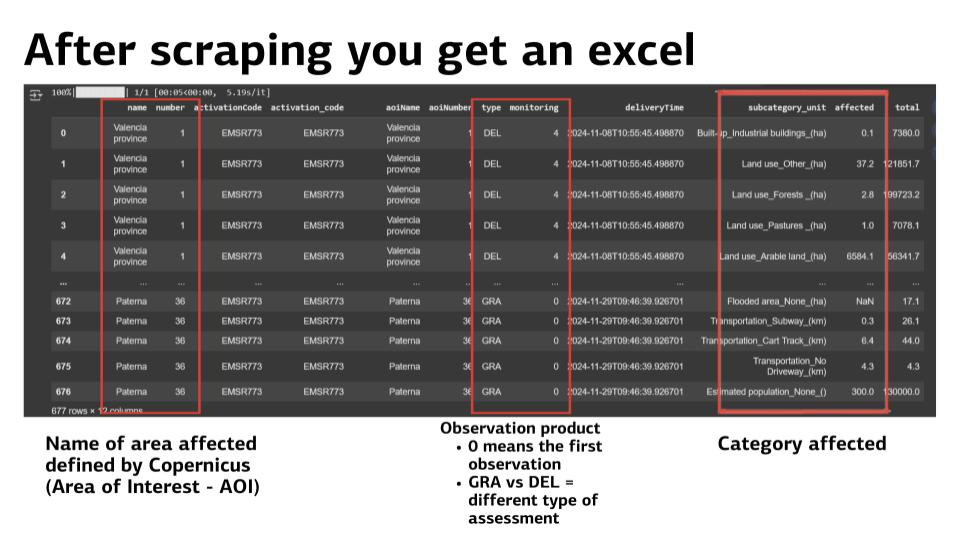

In [93]:
#in order to save the file in your computer you need to create a file
from google.colab import files

file_path = "/content/aois_df_test_for_google_collab_eith_polygons.xlsx" #you can change the name "aois_df_test_for_google_collab" to whatever you want

# save the DataFrame as an Excel file
aois_df.to_excel(file_path, index=False)

# Download the file to your computer
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 2 cleaning of the data!

First take a look at them, understand them

In [32]:
aois_df.head(5)

,name,number,activationCode,activation_code,aoiName,aoiNumber,type,monitoring,deliveryTime,subcategory_unit,affected,total,json_url,all_json_urls
0,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,2026-02-21T13:58:57.271048,Built-up_Military_(ha),0.2,629.1,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
1,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,2026-02-21T13:58:57.271048,Built-up_Residential Buildings_(ha),2.0,1534.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
2,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,2026-02-21T13:58:57.271048,Land use_Other_(ha),74.8,3166.4,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
3,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,2026-02-21T13:58:57.271048,Land use_Forests _(ha),2.2,4192.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...
4,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,0,2026-02-21T13:58:57.271048,Land use_Pastures _(ha),111.1,837.3,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...


In [96]:
aois_df.groupby("activationCode")['name'].value_counts()

activationCode  name        
EMSR692         Larissa         198
                Karditsa        185
                Palamas         171
                Stefanovikio    130
                Magnesia         89
                Kalamaki         26
                Keramidi         18
EMSR697         Lamia            21
                Istiaia          18
                Orchomenus        3
                Trikala           2
EMSR868         Orestiada        82
                Feres            70
Name: count, dtype: int64

In [97]:
aois_df.groupby(["activationCode", "name"])['monitoring'].value_counts()

activationCode  name          monitoring
EMSR692         Kalamaki      1             26
                Karditsa      3             32
                              4             32
                              1             31
                              2             31
                              0             30
                              5             29
                Keramidi      1             18
                Larissa       4             34
                              1             33
                              2             33
                              3             33
                              5             33
                              0             32
                Magnesia      2             30
                              3             30
                              1             27
                              0              1
                              4              1
                Palamas       1             29
                              2             29
                              5             29
                              0             28
                              3             28
                              4             28
                Stefanovikio  0             26
                              1             26
                              2             26
                              3             26
                              4             26
EMSR697         Istiaia       0             18
                Lamia         0             20
                              1              1
                Orchomenus    0              1
                              1              1
                              2              1
                Trikala       0              1
                              1              1
EMSR868         Feres         0             21
                              3             19
                              2             16
                              1             14
                Orestiada     0             21
                              2             21
                              4             20
                              3             19
                              1              1
Name: count, dtype: int64

First of all here we have a lot of products (days of obervation) and a lot of areas of interest (that can overlap with each other). We want one day of observation, per one area of interest, in one flood so we don't overcount.

How do we choose which product and which AOI?

Let's start from the more specific category and choose the day of observation per AOI first. And then we check which AOIs overlap with each other and we can take them out.  

1. We want the highest number of water extent, we want to see the flood at its peak. And since bigger water extent means bigger population affected we can just simply keep the monitoring number with the biggest population affected per AOI.

check how the population category is written:

In [98]:
aois_df_population = aois_df[aois_df['subcategory_unit'].str.contains("population", case=False, na=False)]
aois_df_population['subcategory_unit'].value_counts()

,count
subcategory_unit,
Estimated population_None_(),38


lets see which aois don't have population data, and since Copernicus seems to have ONCE AGAIN changed its reporting in 2026, for the ones that do not have data on affected column for estimated population we are going to use the subacategory unit called containing "Maximum of all extents**". We don't use it for everything because it doesnt exist for past floods..

In [99]:
pop_na = aois_df_population[aois_df_population['affected'].isna()]
pop_na['activation_code'].unique()

array(['EMSR868'], dtype=object)

In [100]:
pop_na = aois_df_population[aois_df_population['affected'].isna()]
pop_na['name'].unique()

array(['Orestiada', 'Feres'], dtype=object)

The above flood has no data on estimated population of the affected column. It's not correct to use the total column because that corresponds to the entire AOI, meaning the entire area observed and NOT THE FLOODED parts.

This means that we will have to check a different value for them. Since its a new flood, we can use the value "Maximum of all extents" for these two AOIs. Like we said this is a new value, that does not exist in floods until mid of 2025.

In [106]:
# 1. PREPARE POPULATION DATA

aois_df_population['affected'] = pd.to_numeric(aois_df_population['affected'], errors='coerce')

# AOIs that DO have population
pop_clean = aois_df_population.dropna(subset=['affected']).copy() #keep only the products with values

idx_pop = pop_clean.groupby(['activationCode', 'name'])['affected'].idxmax() #check the highest

highest_pop = pop_clean.loc[idx_pop, ['activationCode','name','monitoring','affected']] #keep the row and thus product with the highest affected pop
highest_pop['keep'] = True #create column to mark your product

# 2. PREPARE FALLBACK: AOIs WITHOUT POPULATION
# Extract all "Maximum of all extents" rows, it works for floods between 2025-2026
aois_df_max_extent = aois_df[
    aois_df['subcategory_unit'].str.contains("Maximum of all extents", case=False, na=False)
].copy() #create a smaller df only with the "Maximum of all extents" rows

# Keep only AOIs that are NOT in highest_pop
missing_pop_pairs = aois_df_max_extent.merge(
    highest_pop[['activationCode','name']],
    on=['activationCode','name'],
    how='left',
    indicator=True
)
missing_pop_pairs

fallback = missing_pop_pairs[missing_pop_pairs['_merge'] == 'left_only'].copy() #i create a column named _merged with the value left_only which means that it refers to products and aois without population and I keep only that

# Select the HIGHEST monitoring per AOI
idx_fallback = fallback.groupby(['activationCode','name'])['monitoring'].idxmax()

fallback_max_extent = fallback.loc[idx_fallback, ['activationCode','name','monitoring']]
fallback_max_extent['keep'] = True

# 3. COMBINE POPULATION + FALLBACK

final_keep_table = pd.concat([
    highest_pop[['activationCode','name','monitoring','keep']],
    fallback_max_extent[['activationCode','name','monitoring','keep']]
], ignore_index=True)

# 4. MERGE WITH ORIGINAL CLEAN AOI TABLE

aois_df_merged = aois_df.merge(
    final_keep_table,
    on=['activationCode','name','monitoring'],
    how='left'
)

#save before filtering
aois_df_merged.to_excel("all_products_with_keep_column.xlsx", index=False)

#filter
aois_df_filtered = aois_df_merged[aois_df_merged['keep'] == True].copy()

#save
aois_df_filtered.to_excel("one_product_per_aoi.xlsx", index=False)

#download both files in your computer
from google.colab import files
files.download("all_products_with_keep_column.xlsx")
files.download("one_product_per_aoi.xlsx")


aois_df_filtered

/tmp/ipykernel_2895/3948534930.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aois_df_population['affected'] = pd.to_numeric(aois_df_population['affected'], errors='coerce')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,name,number,activationCode,activation_code,aoiName,aoiNumber,type,monitoring,product_polygon,deliveryTime,subcategory_unit,affected,total,json_url,all_json_urls,keep
62,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Built-up_Military_(ha),0.2,629.1,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
63,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Built-up_Residential Buildings_(ha),2.3,1534.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
64,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Land use_Other_(ha),54.9,3166.4,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
65,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Land use_Forests _(ha),1.5,4192.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
66,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Land use_Pastures _(ha),94.0,837.3,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1008,Kalamaki,7,EMSR692,EMSR692,Kalamaki,7,DEL,1,"POLYGON ((22.513296 39.863184, 22.526055 39.82...",2024-04-24T08:49:41.454660,Transportation_Airfield runways_(km),8.7,8.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
1009,Kalamaki,7,EMSR692,EMSR692,Kalamaki,7,DEL,1,"POLYGON ((22.513296 39.863184, 22.526055 39.82...",2024-04-24T08:49:41.454660,Water Extent**_None_(ha),NaN,18295.6,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
1010,Kalamaki,7,EMSR692,EMSR692,Kalamaki,7,DEL,1,"POLYGON ((22.513296 39.863184, 22.526055 39.82...",2024-04-24T08:49:41.454660,Permanent Water_None_(ha),NaN,4681.0,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
1011,Kalamaki,7,EMSR692,EMSR692,Kalamaki,7,DEL,1,"POLYGON ((22.513296 39.863184, 22.526055 39.82...",2024-04-24T08:49:41.454660,Estimated population_None_(),800.0,19000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True


In [107]:
aois_df_filtered.groupby(["activationCode", "name"])['monitoring'].value_counts()

activationCode  name          monitoring
EMSR692         Kalamaki      1             26
                Karditsa      2             31
                Keramidi      1             18
                Larissa       3             33
                Magnesia      3             30
                Palamas       3             28
                Stefanovikio  1             26
EMSR697         Istiaia       0             18
                Lamia         0             20
EMSR868         Feres         3             19
                Orestiada     4             20
Name: count, dtype: int64

In [115]:
# Keep only AOIs where the subcategory_unit contains "Estimated population"
aois_pop = aois_df_filtered[
    aois_df_filtered['subcategory_unit'].str.contains("Estimated population", case=False, na=False)
].copy()
aois_pop['name'].value_counts()

,count
name,
Orestiada,1
Feres,1
Lamia,1
Istiaia,1
Magnesia,1
Palamas,1
Larissa,1
Stefanovikio,1
Karditsa,1


In [117]:
from shapely import wkt
import geopandas as gpd


gdf = aois_pop.copy()
gdf['geometry'] = gdf['product_polygon'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs="EPSG:4326")

# Ensure population is numeric
gdf['affected'] = pd.to_numeric(gdf['affected'], errors='coerce').fillna(0)
gdf

,name,number,activationCode,activation_code,aoiName,aoiNumber,type,monitoring,product_polygon,deliveryTime,subcategory_unit,affected,total,json_url,all_json_urls,keep,geometry
80,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Estimated population_None_(),0.0,46000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((26.3112 41.24287, 26.30534 41.24448,..."
150,Feres,2,EMSR868,EMSR868,Feres,2,DEL,3,"POLYGON ((26.320323 41.151585, 26.32823 41.150...",2026-02-27T21:15:25.947255,Estimated population_None_(),0.0,25000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((26.32032 41.15158, 26.32823 41.1508,..."
172,Lamia,1,EMSR697,EMSR697,Lamia,1,DEL,0,"POLYGON ((22.648195 38.938562, 22.646607 38.93...",2023-10-05T18:26:00,Estimated population_None_(),80.0,84000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.6482 38.93856, 22.64661 38.9384, ..."
195,Istiaia,4,EMSR697,EMSR697,Istiaia,4,DEL,0,"POLYGON ((22.826701 38.820569, 22.806771 38.85...",2023-09-29T18:37:00,Estimated population_None_(),40.0,31000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.8267 38.82057, 22.80677 38.85273,..."
224,Magnesia,1,EMSR692,EMSR692,Magnesia,1,DEL,3,"POLYGON ((21.465407 39.704952, 21.719982 39.10...",2024-04-24T08:49:41.317128,Estimated population_None_(),12000.0,640000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((21.46541 39.70495, 21.71998 39.10992..."
425,Palamas,2,EMSR692,EMSR692,Palamas,2,DEL,3,"POLYGON ((22.038342 39.674481, 22.334013 39.67...",2024-04-24T08:49:41.335690,Estimated population_None_(),17000.0,42000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.03834 39.67448, 22.33401 39.67175..."
487,Larissa,3,EMSR692,EMSR692,Larissa,3,DEL,3,"POLYGON ((22.521889 39.73338, 22.548283 39.723...",2024-04-24T08:49:41.371208,Estimated population_None_(),14000.0,120000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.52189 39.73338, 22.54828 39.72372..."
704,Stefanovikio,4,EMSR692,EMSR692,Stefanovikio,4,DEL,1,"POLYGON ((22.658811 39.687272, 22.699364 39.62...",2024-04-24T08:49:41.392300,Estimated population_None_(),1000.0,12000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.65881 39.68727, 22.69936 39.62646..."
844,Karditsa,5,EMSR692,EMSR692,Karditsa,5,DEL,2,"POLYGON ((21.742624 39.677209, 21.749242 39.21...",2024-04-24T08:49:41.424232,Estimated population_None_(),14000.0,140000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((21.74262 39.67721, 21.74924 39.2129,..."
985,Keramidi,6,EMSR692,EMSR692,Keramidi,6,DEL,1,"POLYGON ((22.017623 39.595298, 22.185215 39.61...",2024-04-24T08:49:41.449318,Estimated population_None_(),600.0,79000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.01762 39.5953, 22.18522 39.61124,..."


In [118]:
import itertools

overlap_rows = []

for activation, group in gdf.groupby("activationCode"):
    for i, j in itertools.combinations(group.index, 2):
        g1 = group.at[i, 'geometry']
        g2 = group.at[j, 'geometry']

        if not g1.intersects(g2):
            continue

        inter_area = g1.intersection(g2).area
        if inter_area == 0:
            continue

        area1 = g1.area
        area2 = g2.area
        smaller_area = min(area1, area2)

        overlap_pct = (inter_area / smaller_area) * 100

        overlap_rows.append({
            "activationCode": activation,
            "idx1": i,
            "idx2": j,
            "AOI_1": group.at[i, 'name'],
            "AOI_2": group.at[j, 'name'],
            "area1": area1,
            "area2": area2,
            "pop1": group.at[i, 'affected'],
            "pop2": group.at[j, 'affected'],
            "overlap_pct": overlap_pct
        })

overlap_df = pd.DataFrame(overlap_rows)

# only consider overlaps >= 10%
overlap_df_10 = overlap_df[overlap_df['overlap_pct'] >= 10].copy()
overlap_df_10

,activationCode,idx1,idx2,AOI_1,AOI_2,area1,area2,pop1,pop2,overlap_pct
0,EMSR692,224,425,Magnesia,Palamas,1.006876,0.150790,12000.0,17000.0,100.000000
1,EMSR692,224,487,Magnesia,Larissa,1.006876,0.063497,12000.0,14000.0,100.000000
2,EMSR692,224,704,Magnesia,Stefanovikio,1.006876,0.051343,12000.0,1000.0,93.339587
3,EMSR692,224,844,Magnesia,Karditsa,1.006876,0.138384,12000.0,14000.0,100.000000
4,EMSR692,224,985,Magnesia,Keramidi,1.006876,0.029470,12000.0,600.0,100.000000
5,EMSR692,224,1011,Magnesia,Kalamaki,1.006876,0.058847,12000.0,800.0,100.000000
7,EMSR692,425,985,Palamas,Keramidi,0.150790,0.029470,17000.0,600.0,76.035537
9,EMSR692,487,985,Larissa,Keramidi,0.063497,0.029470,14000.0,600.0,12.462714
10,EMSR692,487,1011,Larissa,Kalamaki,0.063497,0.058847,14000.0,800.0,39.730026
11,EMSR692,704,1011,Stefanovikio,Kalamaki,0.051343,0.058847,1000.0,800.0,67.319949


We can either go and check ourselves manually (by looking the flood site in Copernicus https://mapping.emergency.copernicus.eu/activations/EMSR692/aois or we can do something different...a little bit unorthodox... and do it with python.

## How we choose the “right” AOIs (simple explanation)

When Copernicus maps a flood, it often creates **many AOIs** (Areas of Interest) for the same region. Some AOIs are very large and drawn early in the event, while others are smaller and mapped later when the flood is better understood. Because of this, AOIs can overlap, and some may even sit completely inside others. If we kept all of them, we would double‑count the flood impact.

To avoid this, we follow a two‑step logic.  
First, for each AOI we keep **only the best product** — the monitoring that shows the **highest affected population**. This ensures we always use the most informative version of each AOI. (we have already done that above.)

Second, we compare AOIs that overlap. If a large AOI contains several smaller ones (as we see in the table right above), we treat the large one as a “parent” and the smaller ones as “children.” Then we compare their populations:  
- If the **children together** show more affected population than the parent, we keep the children and remove the parent.  
- If the **parent** shows more affected population than all children combined, we keep the parent and remove the children.

This way, we always keep the AOIs that best represent the real flood impact, without duplicates or overlaps.

In [119]:
# This set will store the indices of AOIs that we decide to remove.
# It starts empty, and AOIs get added ONLY after the population comparison.
to_remove = set()

# We process each activation separately (each flood event) / sub for subset → ie the part of overlap_df_10 that contains only the overlaps for that activation
for activation, sub in overlap_df_10.groupby("activationCode"):

    # Select only the AOIs that belong to this activation
    act_gdf = gdf[gdf['activationCode'] == activation]

    # Calculate the physical area of each AOI polygon.
    # (Each AOI is a polygon made from its coordinate points, and GeoPandas
    # can compute how big that polygon is on the map.)
    # Larger AOIs are treated as "parent candidates".
    areas = act_gdf['geometry'].area
    parent_candidates = areas.sort_values(ascending=False).index.tolist()

    # Loop through AOIs in order of size (largest first)
    for parent_idx in parent_candidates:

        # BEFORE doing anything else:
        # If this AOI was already removed earlier, skip it. The code runs on a loop so parent candidates will be added later, so if they are removed already don't add them again in the second loop.
        # (It gets added to 'to_remove' LATER in the code.)
        if parent_idx in to_remove:
            continue

        # Get the geometry and population of the parent AOI
        parent_geom = act_gdf.at[parent_idx, 'geometry']
        parent_pop = act_gdf.at[parent_idx, 'affected']

        # Find all overlapping AOIs (children) for this parent / rel stands for relationship
        rel = sub[
            ((sub['idx1'] == parent_idx) | (sub['idx2'] == parent_idx))
        ].copy() #this code basically says “Give me all rows where the parent AOI is involved in the overlap either in column idx1 or in column idx2.”

        # If no overlaps (relationship.empty), move to the next parent candidate
        if rel.empty:
            continue

        # List to store the indices of child AOIs / As we loop through overlaps, we will add the indices of AOIs that qualify as children of the current parent.
        child_indices = []

        # Loop through each overlapping pair
        for _, row in rel.iterrows():

            # Identify which AOI is the child in this pair
            if row['idx1'] == parent_idx:
                child_idx = row['idx2']
                child_area = row['area2']
            else:
                child_idx = row['idx1']
                child_area = row['area1']
                #Each overlap row has two AOIs: idx1 and idx2.
                #One of them is the parent (the one we are currently evaluating). The other one is the potential child.
                #So: If the parent appears in idx1, then the child is idx2. If the parent appears in idx2, then the child is idx1.
                #We also extract the child’s area so we can compare sizes later.

            # Only treat it as a child if:
            # 1. It hasn't been removed already / again this is a loop
            # 2. It is smaller than the parent
            if child_idx not in to_remove and child_area <= parent_geom.area:
                child_indices.append(child_idx)

        # If no valid children, skip to next parent
        if not child_indices:
            continue

        # Sum the population of all child AOIs / because if their population affected is larger than the one parent we will keep the children AOIs
        children_pop = act_gdf.loc[child_indices, 'affected'].sum()

        # THIS IS WHERE WE DECIDE WHO TO REMOVE

        # If children together have MORE population than the parent:
        if children_pop >= parent_pop:
            # Remove the parent (add it to the removal set)
            to_remove.add(parent_idx)

        else:
            # Otherwise, remove all children
            to_remove.update(child_indices)

# After the loop finishes, drop all AOIs that were marked for removal
gdf_final = gdf.drop(index=to_remove).copy()
gdf_final


/tmp/ipykernel_2895/1756647986.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = act_gdf['geometry'].area


,name,number,activationCode,activation_code,aoiName,aoiNumber,type,monitoring,product_polygon,deliveryTime,subcategory_unit,affected,total,json_url,all_json_urls,keep,geometry
80,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Estimated population_None_(),0.0,46000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((26.3112 41.24287, 26.30534 41.24448,..."
150,Feres,2,EMSR868,EMSR868,Feres,2,DEL,3,"POLYGON ((26.320323 41.151585, 26.32823 41.150...",2026-02-27T21:15:25.947255,Estimated population_None_(),0.0,25000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((26.32032 41.15158, 26.32823 41.1508,..."
172,Lamia,1,EMSR697,EMSR697,Lamia,1,DEL,0,"POLYGON ((22.648195 38.938562, 22.646607 38.93...",2023-10-05T18:26:00,Estimated population_None_(),80.0,84000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.6482 38.93856, 22.64661 38.9384, ..."
195,Istiaia,4,EMSR697,EMSR697,Istiaia,4,DEL,0,"POLYGON ((22.826701 38.820569, 22.806771 38.85...",2023-09-29T18:37:00,Estimated population_None_(),40.0,31000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.8267 38.82057, 22.80677 38.85273,..."
425,Palamas,2,EMSR692,EMSR692,Palamas,2,DEL,3,"POLYGON ((22.038342 39.674481, 22.334013 39.67...",2024-04-24T08:49:41.335690,Estimated population_None_(),17000.0,42000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.03834 39.67448, 22.33401 39.67175..."
487,Larissa,3,EMSR692,EMSR692,Larissa,3,DEL,3,"POLYGON ((22.521889 39.73338, 22.548283 39.723...",2024-04-24T08:49:41.371208,Estimated population_None_(),14000.0,120000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.52189 39.73338, 22.54828 39.72372..."
704,Stefanovikio,4,EMSR692,EMSR692,Stefanovikio,4,DEL,1,"POLYGON ((22.658811 39.687272, 22.699364 39.62...",2024-04-24T08:49:41.392300,Estimated population_None_(),1000.0,12000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((22.65881 39.68727, 22.69936 39.62646..."
844,Karditsa,5,EMSR692,EMSR692,Karditsa,5,DEL,2,"POLYGON ((21.742624 39.677209, 21.749242 39.21...",2024-04-24T08:49:41.424232,Estimated population_None_(),14000.0,140000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True,"POLYGON ((21.74262 39.67721, 21.74924 39.2129,..."


In [120]:
gdf_final.groupby(["activationCode", "name"])['monitoring'].value_counts()

activationCode  name          monitoring
EMSR692         Karditsa      2             1
                Larissa       3             1
                Palamas       3             1
                Stefanovikio  1             1
EMSR697         Istiaia       0             1
                Lamia         0             1
EMSR868         Feres         3             1
                Orestiada     4             1
Name: count, dtype: int64

In [124]:
keep_pairs = gdf_final[['activationCode', 'name']]

aois_final_products = aois_df_filtered.merge(
    keep_pairs,
    on=['activationCode', 'name'],
    how='inner'
)
aois_final_products.to_excel("aois_final_products.xlsx", index=False)
files.download("aois_final_products.xlsx")
aois_final_products

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,name,number,activationCode,activation_code,aoiName,aoiNumber,type,monitoring,product_polygon,deliveryTime,subcategory_unit,affected,total,json_url,all_json_urls,keep
0,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Built-up_Military_(ha),0.2,629.1,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
1,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Built-up_Residential Buildings_(ha),2.3,1534.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
2,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Land use_Other_(ha),54.9,3166.4,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
3,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Land use_Forests _(ha),1.5,4192.7,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
4,Orestiada,1,EMSR868,EMSR868,Orestiada,1,DEL,4,"POLYGON ((26.311196 41.242868, 26.305341 41.24...",2026-02-27T22:22:56.403939,Land use_Pastures _(ha),94.0,837.3,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Karditsa,5,EMSR692,EMSR692,Karditsa,5,DEL,2,"POLYGON ((21.742624 39.677209, 21.749242 39.21...",2024-04-24T08:49:41.424232,Transportation_Long-distance railways_(km),17.7,59.0,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
191,Karditsa,5,EMSR692,EMSR692,Karditsa,5,DEL,2,"POLYGON ((21.742624 39.677209, 21.749242 39.21...",2024-04-24T08:49:41.424232,Water Extent**_None_(ha),NaN,9804.2,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
192,Karditsa,5,EMSR692,EMSR692,Karditsa,5,DEL,2,"POLYGON ((21.742624 39.677209, 21.749242 39.21...",2024-04-24T08:49:41.424232,Permanent Water_None_(ha),NaN,123.4,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True
193,Karditsa,5,EMSR692,EMSR692,Karditsa,5,DEL,2,"POLYGON ((21.742624 39.677209, 21.749242 39.21...",2024-04-24T08:49:41.424232,Estimated population_None_(),14000.0,140000,https://rapidmapping-viewer.s3.eu-west-1.amazo...,[https://rapidmapping-viewer.s3.eu-west-1.amaz...,True


In [1]:
from google.colab import files
uploaded = files.upload()

Saving NUTS_RG_01M_2021_4326.shp to NUTS_RG_01M_2021_4326.shp


In [2]:
aois_final_products

NameError: name 'aois_final_products' is not defined

In [ ]:
nuts3 = gpd.read_file("NUTS_RG_03M_2021_4326_LEVL_3.shp")

aois_final_products = aois_final_products.to_crs(nuts3.crs)

aoi_nuts3 = gpd.overlay(aois_final_products, nuts3, how="intersection")